In [169]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [170]:
german_credit = pd.read_csv('german_credit.csv')
german_credit.head(5)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [171]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

In [172]:
german_credit.shape

(1000, 21)

In [173]:
german_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [174]:
german_credit.describe().T

,count,mean,std,min,25%,50%,75%,max
default,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0
duration_in_month,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_as_income_perc,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_res_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
credits_this_bank,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_under_maintenance,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [175]:
#Before we think of splitting the data
#saving the dataframe copy

original_data = german_credit.copy()

In [176]:
X =  german_credit.drop("default", axis=1)
y =  german_credit.pop("default")
train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.50, random_state=2)


In [177]:
#we will validate the split % by loking at the shapes of the split portions
print('Shape of train data:',train_set.shape)
print('Shape of test data:',test_set.shape)

Shape of train data: (500, 20)
Shape of test data: (500, 20)


In [178]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [179]:
data = pd.get_dummies(original_data,drop_first=True)

In [180]:
data.shape

(1000, 49)

In [181]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
default                                                                       1000 non-null int64
duration_in_month                                                             1000 non-null int64
credit_amount                                                                 1000 non-null int64
installment_as_income_perc                                                    1000 non-null int64
present_res_since                                                             1000 non-null int64
age                                                                           1000 non-null int64
credits_this_bank                                                             1000 non-null int64
people_under_maintenance                                                      1000 non-null int64
account_check_status_< 0 DM                                                   1000 non-null uint8
account_chec

### Check for highly correlated variables but don't required any treatment for this use case

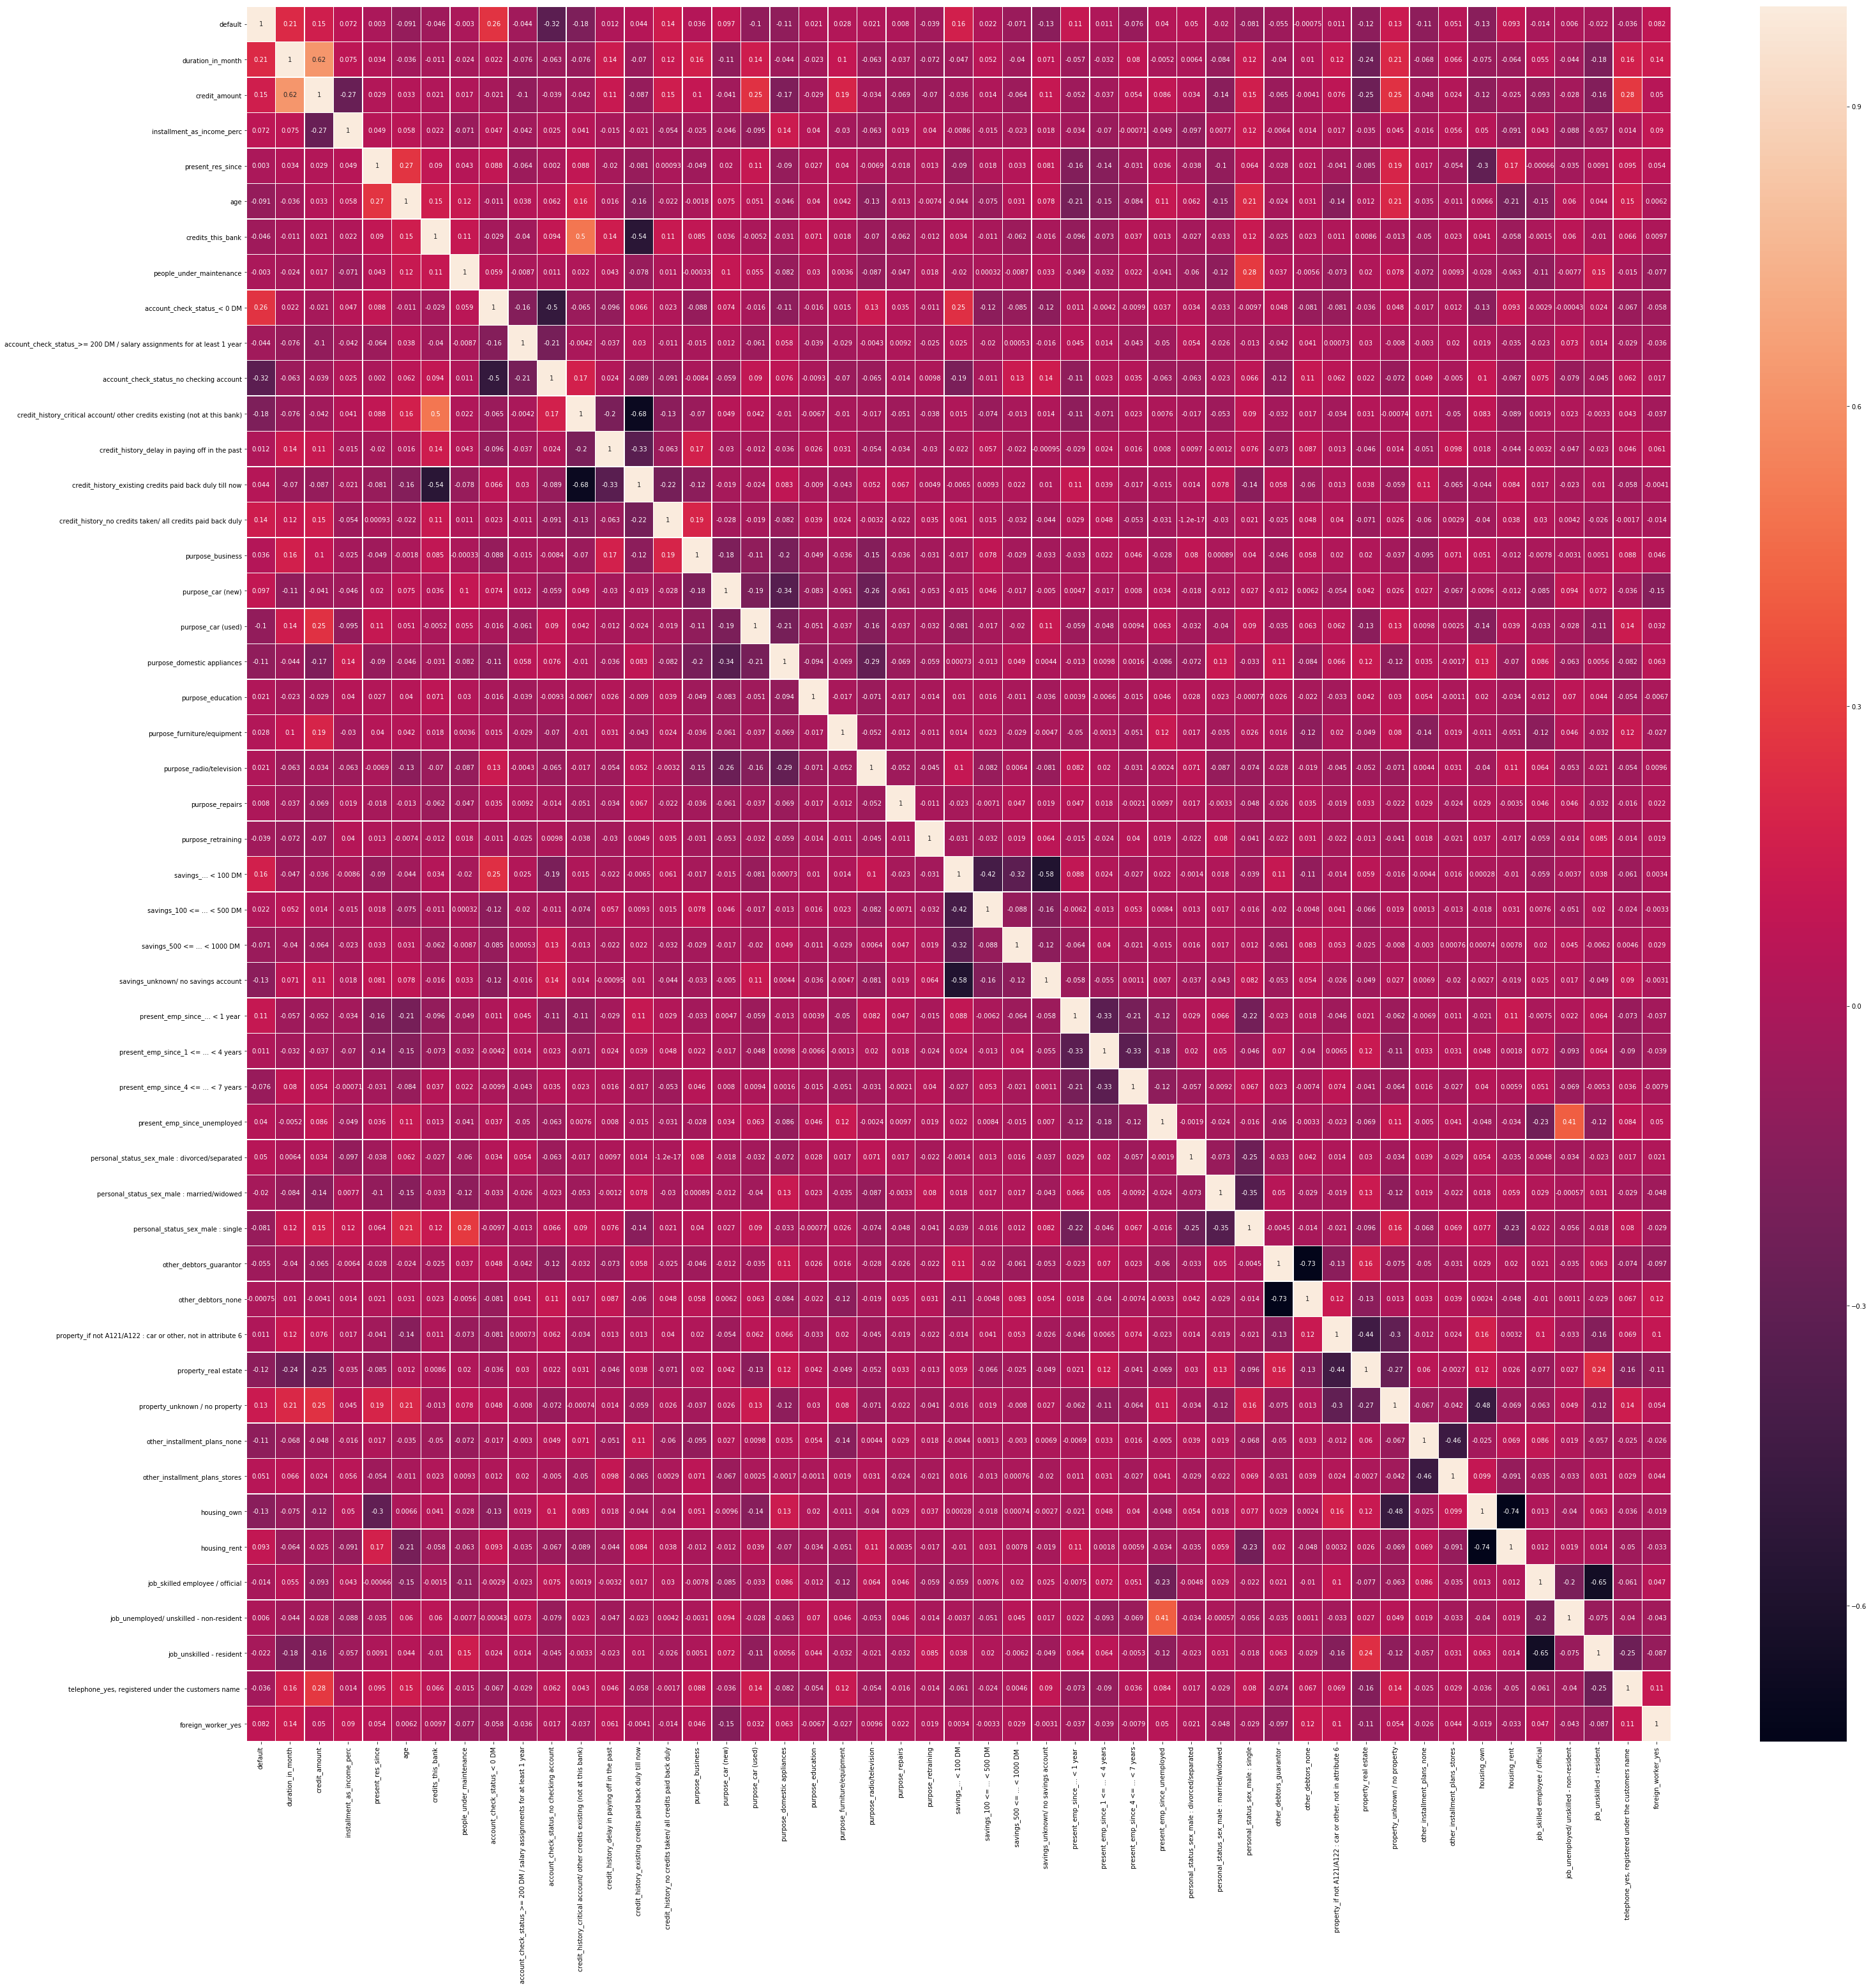

In [182]:
correlation = data.corr()
fig, ax = plt.subplots(figsize=(50,50))
sns.heatmap(correlation,annot=True,linewidths=0.5,ax=ax)

In [184]:
# Create correlation matrix with all strongly correlated values (i.e. both -ve and +ve
# values converted to absolute counterparts so as to compare with a thresold like 0.95)
corr_matrix = data.corr().abs()
#Now using the Datframe.where() method, we replace all the elements of this corr_matrix,
#which are "on-or-below" the main digonal to NaNs, while retaining the original absolute values
#on the "upper-triangle" of the correlation-matrix (i.e. only one set of value on upper or lower triangles
#represents all the possible correlation values)
upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
# Find index of feature columns with correlation greater than 0.95
#we get a "list" of features which can be dropped.
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(to_drop)

##The *empty* list tells us that there aren't any features which are "strongly correlated" with each other
#hence **none to drop**.

[]


### Drop the original variables which are converted to dummy

In [185]:
#when we did get dummies, with the use of drop_first=True , have dropped the original variables for each feature.

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [186]:
X = data.drop('default',axis=1)
y = data['default']

In [187]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [188]:
print('Shape of train data:',X_train.shape)
print('Shape of test data:',X_test.shape)

Shape of train data: (700, 48)
Shape of test data: (300, 48)


### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [189]:
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999)
RF_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [190]:
y_predict = RF_model.predict(X_test)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [191]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,auc,roc_curve

In [192]:
accuracy_score(y_test,y_predict)

0.7833333333333333

In [193]:
confusion_matrix(y_test,y_predict)

array([[196,  18],
       [ 47,  39]], dtype=int64)

### Q6 Show the list of the features importance( 1 Marks)

In [194]:
RF_model.feature_importances_

array([0.08907278, 0.11521964, 0.03855812, 0.04010698, 0.08687789,
       0.02126302, 0.01537522, 0.03900078, 0.01054737, 0.05288285,
       0.02263583, 0.01091322, 0.01703491, 0.01212418, 0.01088784,
       0.01800316, 0.01541311, 0.01577456, 0.00569541, 0.00269244,
       0.01476537, 0.00309069, 0.00145906, 0.01910153, 0.00982032,
       0.00748116, 0.01614258, 0.01807808, 0.01724729, 0.0151559 ,
       0.00735704, 0.00813193, 0.01009041, 0.01865575, 0.01023359,
       0.01118119, 0.01805395, 0.0209287 , 0.01349353, 0.02023166,
       0.00685452, 0.01630517, 0.01384402, 0.01904209, 0.00306532,
       0.01434421, 0.02116294, 0.00460272])

In [195]:
print (pd.Series(RF_model.feature_importances_,index = list(X)).sort_values(ascending=False))

credit_amount                                                                 0.115220
duration_in_month                                                             0.089073
age                                                                           0.086878
account_check_status_no checking account                                      0.052883
present_res_since                                                             0.040107
account_check_status_< 0 DM                                                   0.039001
installment_as_income_perc                                                    0.038558
credit_history_critical account/ other credits existing (not at this bank)    0.022636
credits_this_bank                                                             0.021263
telephone_yes, registered under the customers name                            0.021163
property_real estate                                                          0.020929
other_installment_plans_none               

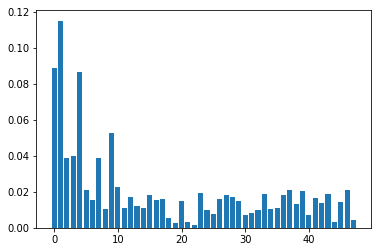

In [197]:
# importance of features in the tree building 
plt.bar(range(len(RF_model.feature_importances_)), RF_model.feature_importances_)
plt.show()

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [198]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,auc,roc_curve,roc_auc_score

In [199]:
# Use below values
num_folds = 10
seed = 77

In [200]:
#Validate the Random Forest model build above using k fold

#For each fold calculated the accuracy,recall,precision and f1score.
#Each of these values are stored in the array arr
#to find out the best score,used F1score metric as it takes both recall and precision into consideration.
#the same set of labels are also stored.

In [ ]:
arr = []
best_f1_Score = 0
#ResultsDf = pd.DataFrame(index=[num_folds])
kf = KFold(n_splits=num_folds,random_state=seed)
for train_index,test_index in kf.split(X):
    Xtrain,Ytrain = X.loc[train_index],y.loc[train_index]
    Xtest,Ytest = X.loc[test_index],y.loc[test_index]
    RF_model.fit(Xtrain,Ytrain)
    y_pred = RF_model.predict(Xtest)
    cmRF=metrics.confusion_matrix(Ytest,y_pred)
    accuracyRF = accuracy_score(Ytest,y_pred)
    precisionRF = precision_score(Ytest,y_pred)
    recallRF = recall_score(Ytest,y_pred)
    f1RF = f1_score(Ytest,y_pred)
    results = [accuracyRF,precisionRF,recallRF,f1RF]
    arr.append(results)
    if(best_f1_Score < f1RF):
        best_f1_Score = f1RF
        Xtrain_final = Xtrain
        Ytrain_final = Ytrain
        Xtest_final  = Xtest
        Ytest_final  = Ytest
        y_pred_final = y_pred

In [201]:
#The list of each scores are stored into a dataframe and did a plot for good visual representation.
ResultsDf = pd.DataFrame(arr,columns=['Accuracy','Precision','Recall','F1Score'])
ResultsDf

,Accuracy,Precision,Recall,F1Score
0,0.87,0.800000,0.640000,0.711111
1,0.67,0.470588,0.250000,0.326531
2,0.79,0.545455,0.521739,0.533333
3,0.81,0.680000,0.607143,0.641509
4,0.81,1.000000,0.321429,0.486486
5,0.68,0.846154,0.268293,0.407407
6,0.75,0.692308,0.300000,0.418605
7,0.78,0.812500,0.406250,0.541667
8,0.75,0.611111,0.379310,0.468085
9,0.76,0.750000,0.375000,0.500000


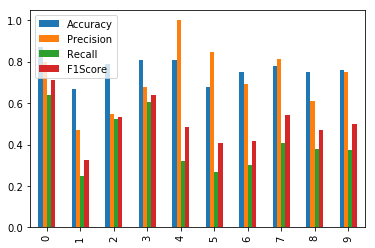

In [202]:
ResultsDf.plot.bar()

In [203]:
#from the dataframe as well as the graph we can see that the accuracy lies in the range of 67 to 87
#which is not really good for a model

In [205]:
#used accuracy as a metric to cross validate the and find out the mean and standard deviation for the model.

from sklearn import model_selection
scoring = 'accuracy'
kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
cv_results = model_selection.cross_val_score(RF_model, X, y, cv=kfold, scoring=scoring)
print('Mean:',cv_results.mean(),'Standard Deviation:', cv_results.std())

Mean: 0.767 Standard Deviation: 0.057105166141076934


In [206]:
#Calculate Mean score
ResultsDf['Accuracy'].mean()

0.767

In [207]:
# Calculate score standard deviation using std()
ResultsDf['Accuracy'].std()

0.060194130389377105

# Q8 Print the confusion matrix( 1 Marks)

In [208]:
confusion_matrix(Ytest_final,y_pred_final)

array([[71,  4],
       [ 9, 16]], dtype=int64)

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [209]:
print('Best Recall score:',recall_score(Ytest_final,y_pred_final))

Best Recall score: 0.64


In [210]:
print('Best Precision score:',precision_score(Ytest_final,y_pred_final))

Best Precision score: 0.8


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [211]:
#Hint: Use roc_curve

In [231]:
y_predictprob = RF_model.predict_proba(X_test)

In [232]:
fpr, tpr, thresholds = roc_curve(y_test,y_predictprob[::,1])

In [233]:
roc_auc = auc(fpr,tpr)
print('ROC:',roc_auc)

ROC: 0.7858889371875679


ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

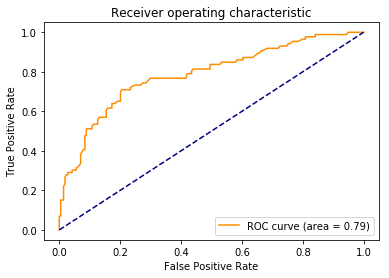

In [234]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [ ]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [ ]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())